Loading artifacts from /workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz...


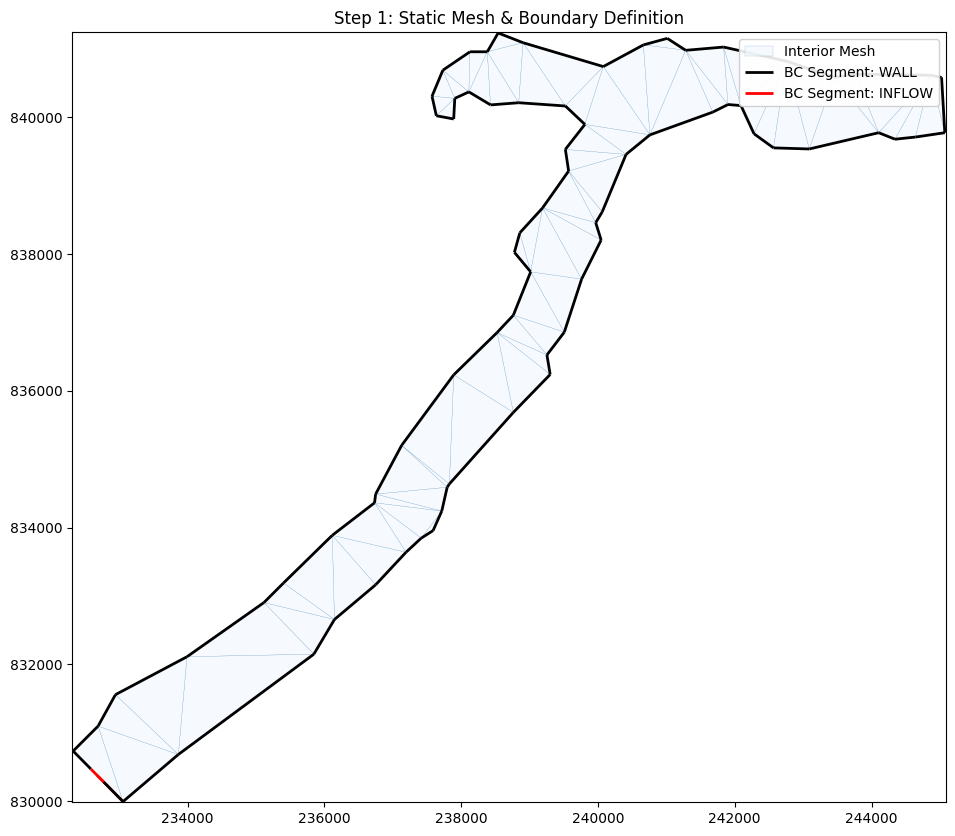

Initializing Sampler...
Adapting artifacts for Sampler compatibility...
  - Mapping bc_wall_starts to generic wall BC
  - Mapping bc_inflow_starts to inflow_starts
Loading sampler artifacts from: /tmp/tmpkt1cknkf.npz
  - Registered boundary 'wall': 75 segments
  - Registered boundary 'inflow': 1 segments
Sampling Interior...
Sampling General Boundaries (Walls)...


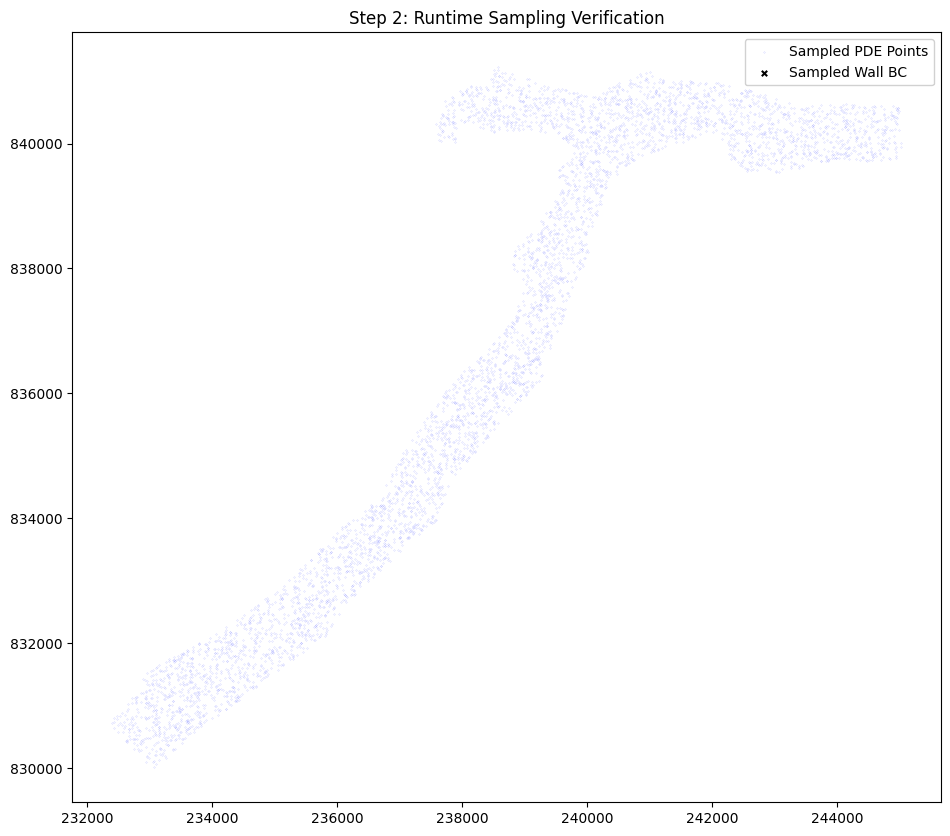

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection, LineCollection
import jax
import jax.numpy as jnp
import tempfile

# --- Setup Paths ---
# Add project root to path to import src
try:
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    project_root = "/workspaces/swe-pinn"

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Manually set DTYPE for src.data
import src.config
src.config.DTYPE = jnp.float32

from src.data import IrregularDomainSampler

# Path to your artifacts
ARTIFACTS_PATH = "/workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz"

def create_legacy_compatible_artifacts(path):
    """
    Creates a temporary artifacts file that maps specific boundary types
    (e.g., bc_wall_starts) to the generic keys expected by IrregularDomainSampler 
    (bc_starts, inflow_starts).
    """
    print("Adapting artifacts for Sampler compatibility...")
    data = np.load(path)
    new_data = dict(data)
    
    # 1. Aggregating Walls (bc_starts)
    # The sampler expects 'bc_starts' and 'bc_vectors' for general walls.
    # We combine all bc_* that are NOT inflow.
    wall_starts = []
    wall_vectors = []
    
    found_any_wall = False
    
    if 'bc_starts' in data:
        # Already compatible
        return path 

    for key in data.files:
        if key.startswith("bc_") and key.endswith("_starts"):
            label = key[3:-7]
            if label == 'inflow':
                continue
            
            print(f"  - Mapping {key} to generic wall BC")
            wall_starts.append(data[f"bc_{label}_starts"])
            wall_vectors.append(data[f"bc_{label}_vectors"])
            found_any_wall = True

    if found_any_wall:
        new_data['bc_starts'] = np.concatenate(wall_starts, axis=0)
        new_data['bc_vectors'] = np.concatenate(wall_vectors, axis=0)

    # 2. Mapping Inflow (inflow_starts)
    # The sampler conditionally checks for 'inflow_starts'.
    if 'bc_inflow_starts' in data:
        print("  - Mapping bc_inflow_starts to inflow_starts")
        new_data['inflow_starts'] = data['bc_inflow_starts']
        new_data['inflow_vectors'] = data['bc_inflow_vectors']

    # Save to temp file
    fd, tmp_path = tempfile.mkstemp(suffix='.npz')
    os.close(fd)
    np.savez(tmp_path, **new_data)
    return tmp_path

def plot_mesh_and_boundaries(data):
    """
    Plots the static mesh (triangles) and all boundary segments found in the file.
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 1. Plot Interior Mesh (Triangles)
    tri_coords = data['tri_coords']
    mesh_col = PolyCollection(tri_coords, 
                              facecolors='aliceblue', 
                              edgecolors='steelblue', 
                              linewidths=0.2, 
                              alpha=0.6,
                              label='Interior Mesh')
    ax.add_collection(mesh_col)

    # 2. Plot Boundaries (Dynamic)
    colors = ['black', 'red', 'green', 'purple', 'orange'] # Color cycle for different BCs
    color_idx = 0
    
    # Scan for keys starting with 'bc_'
    for key in data.files:
        if key.startswith("bc_") and key.endswith("_starts"):
            label = key[3:-7] # extract 'wall', 'inflow', etc.
            
            starts = data[f"bc_{label}_starts"]
            vecs = data[f"bc_{label}_vectors"]
            ends = starts + vecs
            
            # Create segments [(x1,y1), (x2,y2)]
            segments = np.stack((starts, ends), axis=1)
            
            # Assign color
            c = colors[color_idx % len(colors)]
            
            # Plot
            lc = LineCollection(segments, colors=c, linewidths=2, label=f"BC Segment: {label.upper()}")
            ax.add_collection(lc)
            
            # Add arrows for Inflow to distinguish it
            if 'inflow' in label.lower():
                 mid = starts + vecs * 0.5
                 ax.quiver(mid[:,0], mid[:,1], vecs[:,0], vecs[:,1], color=c, scale=20, width=0.003)
            
            color_idx += 1

    # Formatting
    all_pts = tri_coords.reshape(-1, 2)
    ax.set_xlim(all_pts[:,0].min()-10, all_pts[:,0].max()+10)
    ax.set_ylim(all_pts[:,1].min()-10, all_pts[:,1].max()+10)
    ax.set_aspect('equal')
    ax.set_title("Step 1: Static Mesh & Boundary Definition")
    ax.legend(loc='upper right', framealpha=0.9)
    return fig

def plot_sampling_test(sampler):
    """
    Generates samples using the sampler and plots them.
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    
    key = jax.random.PRNGKey(42)
    k_pde, k_bc = jax.random.split(key)
    
    # 1. Sample Interior (PDE)
    print("Sampling Interior...")
    pde_pts = sampler.sample_interior(k_pde, n_points=5000, t_bounds=(0,1))
    
    ax.scatter(pde_pts[:,0], pde_pts[:,1], s=1, c='aliceblue', edgecolors='blue', linewidths=0.1, alpha=0.5, label='Sampled PDE Points')

    # 2. Sample General Boundaries (aggregated walls)
    print("Sampling General Boundaries (Walls)...")
    k_bc, k_sub = jax.random.split(k_bc)
    bc_pts = sampler.sample_boundary(k_sub, n_points=1000, t_bounds=(0,1), boundary_type='general')
    ax.scatter(bc_pts[:,0], bc_pts[:,1], s=15, c='black', marker='x', label='Sampled Wall BC')

    # 3. Sample Inflow (if exists)
    if getattr(sampler, 'has_inflow', False):
        print("Sampling Inflow...")
        k_bc, k_sub = jax.random.split(k_bc)
        inflow_pts = sampler.sample_boundary(k_sub, n_points=500, t_bounds=(0,1), boundary_type='inflow')
        ax.scatter(inflow_pts[:,0], inflow_pts[:,1], s=25, c='red', marker='o', label='Sampled Inflow BC')

    ax.set_aspect('equal')
    ax.set_title("Step 2: Runtime Sampling Verification")
    ax.legend(loc='upper right', framealpha=0.9)
    return fig

def main():
    if not os.path.exists(ARTIFACTS_PATH):
        print(f"Error: Artifacts not found at {ARTIFACTS_PATH}")
        return

    print(f"Loading artifacts from {ARTIFACTS_PATH}...")
    raw_data = np.load(ARTIFACTS_PATH)
    
    # 1. Plot Mesh (using raw data to show specific labels)
    fig1 = plot_mesh_and_boundaries(raw_data)
    plt.show()
    
    # 2. Plot Samples
    print("Initializing Sampler...")
    # Use adapter to fix missing keys
    compat_path = create_legacy_compatible_artifacts(ARTIFACTS_PATH)
    
    try:
        sampler = IrregularDomainSampler(compat_path)
        fig2 = plot_sampling_test(sampler)
        plt.show()
    finally:
        # Cleanup temp file if it's not the original
        if compat_path != ARTIFACTS_PATH and os.path.exists(compat_path):
            os.remove(compat_path)

if __name__ == "__main__":
    main()

Initializing Sampler...
Loading sampler artifacts from: /workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz
  - Registered boundary 'wall': 75 segments
  - Registered boundary 'inflow': 1 segments
Found boundaries: ['wall', 'inflow']


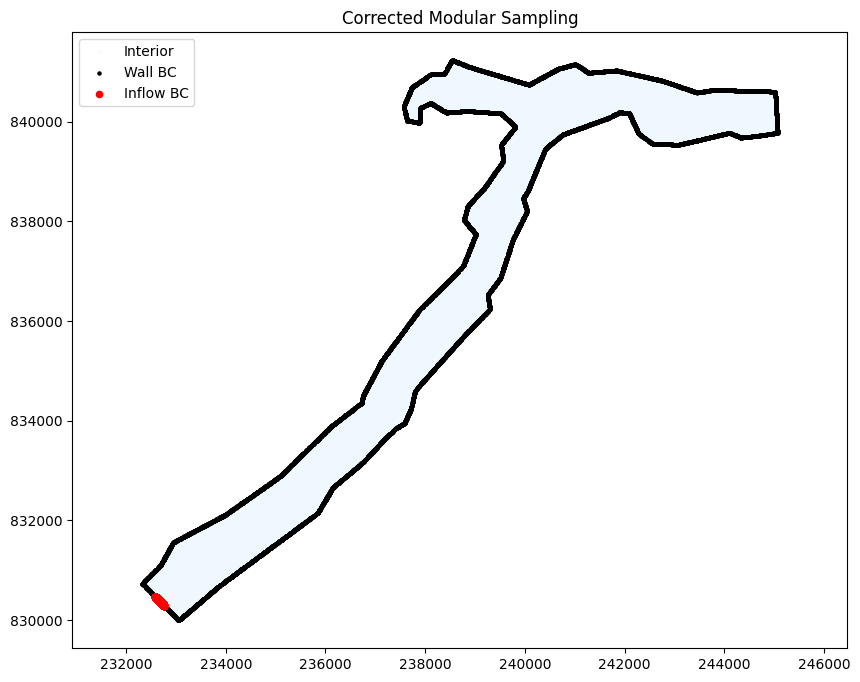

In [2]:
import os
import sys
import matplotlib.pyplot as plt
import jax
import src.config
import jax.numpy as jnp

# Ensure DTYPE is set
src.config.DTYPE = jnp.float32
from src.data import IrregularDomainSampler

# Path to the NEW artifacts (generated by your successful preprocessing run)
ARTIFACTS_PATH = "/workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz"

def main():
    print("Initializing Sampler...")
    # Direct load - no compatibility wrappers needed!
    sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    
    print(f"Found boundaries: {list(sampler.boundaries.keys())}")

    # Generate samples
    key = jax.random.PRNGKey(42)
    k1, k2, k3 = jax.random.split(key, 3)
    
    # 1. PDE
    pts_pde = sampler.sample_interior(k1, 500000, (0,1))
    
    # 2. Wall (The Domain)
    pts_wall = sampler.sample_boundary(k2, 10000, (0,1), 'wall')
    
    # 3. Inflow (The Polyline)
    pts_inflow = sampler.sample_boundary(k3, 5000, (0,1), 'inflow')
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(pts_pde[:,0], pts_pde[:,1], s=1, c='aliceblue', alpha=0.9, label='Interior')
    plt.scatter(pts_wall[:,0], pts_wall[:,1], s=5, c='black', label='Wall BC')
    plt.scatter(pts_inflow[:,0], pts_inflow[:,1], s=20, c='red', label='Inflow BC')
    
    plt.legend()
    plt.axis('equal')
    plt.title("Corrected Modular Sampling")
    plt.show()
    
if __name__ == "__main__":
    main()

In [17]:
import time
import os
import sys
import jax
import jax.numpy as jnp

# --- 1. Setup Environment ---
# Add project root to path so we can import src
try:
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    project_root = "/workspaces/swe-pinn"

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Set DTYPE manually before importing data classes
import src.config
src.config.DTYPE = jnp.float32

from src.data import IrregularDomainSampler

# Path to artifacts (Adjust if your file is named differently)
ARTIFACTS_PATH = "/workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz"

def main():
    if not os.path.exists(ARTIFACTS_PATH):
        print(f"Error: Artifacts not found at {ARTIFACTS_PATH}")
        return

    print(f"Loading sampler from {ARTIFACTS_PATH}...")
    sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    
    # --- Configuration for "One Epoch" ---
    N_BATCHES = 100       # How many batches in one epoch
    N_PDE = 50000          # Points per batch
    N_WALL = 10000
    N_INFLOW = 5000
    T_BOUNDS = (0, 10)
    
    # Initialize Random Keys
    key = jax.random.PRNGKey(42)
    
    # ---------------------------------------------------------
    # 2. Define the Sampling Step (Pure Python Function)
    # ---------------------------------------------------------
    def generate_batch(k):
        k1, k2, k3 = jax.random.split(k, 3)
        # Sample Interior
        pde = sampler.sample_interior(k1, n_points=N_PDE, t_bounds=T_BOUNDS)
        # Sample Wall
        wall = sampler.sample_boundary(k2, n_points=N_WALL, t_bounds=T_BOUNDS, boundary_type='wall')
        # Sample Inflow (if exists)
        inflow = sampler.sample_boundary(k3, n_points=N_INFLOW, t_bounds=T_BOUNDS, boundary_type='inflow')
        return pde, wall, inflow

    # ---------------------------------------------------------
    # 3. Define the Jitted Version
    # ---------------------------------------------------------
    # We JIT the function. JAX will compile the random.choice internals into efficient XLA code.
    generate_batch_jitted = jax.jit(generate_batch)

    print(f"\n--- Benchmarking 1 Epoch ({N_BATCHES} batches) ---")
    print(f"Batch Size: {N_PDE} PDE + {N_WALL} Wall + {N_INFLOW} Inflow points")

    # ---------------------------------------------------------
    # Test A: No-JIT (Standard Python Mode)
    # ---------------------------------------------------------
    print("\nRunning NO-JIT Loop...")
    start_time = time.time()
    
    curr_key = key
    for _ in range(N_BATCHES):
        curr_key, subkey = jax.random.split(curr_key)
        # Calling the python function directly
        _ = generate_batch(subkey)
        
    # Block to ensure GPU is finished (though standard mode is mostly sync)
    jax.block_until_ready(_) 
    end_time = time.time()
    time_nojit = end_time - start_time
    print(f"Time (No JIT): {time_nojit:.4f} seconds")

    # ---------------------------------------------------------
    # Test B: Jitted (XLA Compiled Mode)
    # ---------------------------------------------------------
    print("\nRunning JITTED Loop...")
    
    # Warmup (Compile the function first)
    print("  Compiling (Warmup)...")
    curr_key, subkey = jax.random.split(key)
    _ = generate_batch_jitted(subkey)
    jax.block_until_ready(_)
    
    # Actual Timing
    print("  Executing...")
    start_time = time.time()
    
    curr_key = key
    for _ in range(N_BATCHES):
        curr_key, subkey = jax.random.split(curr_key)
        # Calling the compiled function
        _ = generate_batch_jitted(subkey)
        
    jax.block_until_ready(_)
    end_time = time.time()
    time_jit = end_time - start_time
    print(f"Time (JIT):    {time_jit:.4f} seconds")

    # ---------------------------------------------------------
    # Summary
    # ---------------------------------------------------------
    print("\n--- Results ---")
    print(f"Speedup Factor: {time_nojit / time_jit:.2f}x")
    print("Conclusion: " + ("JIT is working properly." if time_jit < time_nojit else "Something is wrong (JIT is slower)."))

if __name__ == "__main__":
    main()

Loading sampler from /workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz...
Loading sampler artifacts from: /workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz
  - Registered boundary 'wall': 74 segments
  - Registered boundary 'inflow': 1 segments

--- Benchmarking 1 Epoch (100 batches) ---
Batch Size: 50000 PDE + 10000 Wall + 5000 Inflow points

Running NO-JIT Loop...
Time (No JIT): 0.4079 seconds

Running JITTED Loop...
  Compiling (Warmup)...
  Executing...
Time (JIT):    0.0140 seconds

--- Results ---
Speedup Factor: 29.16x
Conclusion: JIT is working properly.


In [9]:
import os
import sys
import jax
import jax.numpy as jnp
from flax.core import FrozenDict
import yaml

# 1. Setup Path to 'src'
# Assuming the notebook is in 'swe-pinn/notebook/' and src is in 'swe-pinn/src'
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import load_config
import src.models as models

# 2. Load Configuration
config_path = "../configs/benchmark_test_5.yaml" 
print(f"Loading config from: {config_path}")
cfg = load_config(config_path)

# --- FIX: INJECT MISSING DOMAIN PARAMETERS ---
# These are usually calculated from the mesh file at runtime.
# For a model summary, we can set them to 1.0 or representative values.
if 'domain' not in cfg: cfg['domain'] = {}
cfg['domain']['lx'] = 1.0
cfg['domain']['ly'] = 1.0
cfg['domain']['t_final'] = 1.0
cfg['domain']['x_min'] = 0.0
cfg['domain']['y_min'] = 0.0

# 3. Initialize the Model
model_name = cfg['model']['name']
print(f"Initializing Model: {model_name}")

try:
    model_class = getattr(models, model_name)
except AttributeError:
    raise ValueError(f"Model '{model_name}' not found in src.models")

rng = jax.random.PRNGKey(0)
frozen_config = FrozenDict(cfg)

# Initialize
# Input shape (1, 3) represents (x, y, t)
model, params_container = models.init_model(model_class, rng, frozen_config)
params = params_container['params']

# 4. Generate Parameter Summary
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))

total_params = count_params(params)

print("\n" + "="*40)
print(f" MODEL SUMMARY: {model_name}")
print("="*40)
print(f"Total Parameters: {total_params:,}")
print("-" * 55)
print(f"{'Layer / Parameter':<30} | {'Shape':<15} | {'Count':<10}")
print("-" * 55)

leaves, _ = jax.tree_util.tree_flatten_with_path(params)

for path, param in leaves:
    # Construct name from path
    name_parts = []
    for p in path:
        if hasattr(p, 'key'):
            name_parts.append(str(p.key))
        elif hasattr(p, 'idx'):
            name_parts.append(str(p.idx))
        else:
            name_parts.append(str(p))
            
    name = "/".join(name_parts)
    print(f"{name:<30} | {str(param.shape):<15} | {param.size:<10,}")

print("="*55)

Loading config from: ../configs/benchmark_test_5.yaml
Initializing Model: DGMNetwork

 MODEL SUMMARY: DGMNetwork
Total Parameters: 1,332,995
-------------------------------------------------------
Layer / Parameter              | Shape           | Count     
-------------------------------------------------------
DGMLayer_0/Ug/bias             | (256,)          | 256       
DGMLayer_0/Ug/kernel           | (3, 256)        | 768       
DGMLayer_0/Uh/bias             | (256,)          | 256       
DGMLayer_0/Uh/kernel           | (3, 256)        | 768       
DGMLayer_0/Ur/bias             | (256,)          | 256       
DGMLayer_0/Ur/kernel           | (3, 256)        | 768       
DGMLayer_0/Uz/bias             | (256,)          | 256       
DGMLayer_0/Uz/kernel           | (3, 256)        | 768       
DGMLayer_0/Wg/kernel           | (256, 256)      | 65,536    
DGMLayer_0/Wh/kernel           | (256, 256)      | 65,536    
DGMLayer_0/Wr/kernel           | (256, 256)      | 65,536    
DGM

In [15]:
import os
import sys
import jax
import jax.numpy as jnp
from flax.core import FrozenDict
import pandas as pd
import yaml

# 1. Setup
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import load_config
import src.models as models

# 2. Load Config & Init Model
config_path = "../configs/benchmark_test_5.yaml" 
cfg = load_config(config_path)
if 'domain' not in cfg: cfg['domain'] = {}
cfg['domain'].update({'lx': 1.0, 'ly': 1.0, 't_final': 1.0, 'x_min': 0.0, 'y_min': 0.0})

model_name = cfg['model']['name']
model_class = getattr(models, model_name)
rng = jax.random.PRNGKey(0)
model, params_container = models.init_model(model_class, rng, FrozenDict(cfg))
params = params_container['params']

# 3. Pure Python "Graph" Visualization
def print_ascii_graph(params, model_name):
    print(f"\n MODEL FLOWCHART: {model_name}")
    print(" " + "="*50)
    
    # --- Input Node ---
    current_dim = 3 # (x, y, t)
    print(f"  [ Input ]")
    print(f"      | (x, y, t)")
    print(f"      v   dim: {current_dim}")

    # --- Fourier Features (Optional) ---
    if 'fourier_features' in params:
        B = params['fourier_features']['B'] # Shape (input, hidden/2)
        out_dim = B.shape[1] * 2
        print(f"  [ Fourier Features ]")
        print(f"      | Sin/Cos Projection")
        print(f"      v   dim: {out_dim}")
        current_dim = out_dim
    
    # --- Hidden Layers ---
    # Sort keys to ensure correct order (dense_layers_0, dense_layers_1...)
    layer_keys = [k for k in params.keys() if 'dense' in k or 'layers' in k]
    
    def get_layer_idx(key):
        parts = key.split('_')
        for p in parts:
            if p.isdigit(): return int(p)
        return 9999
    layer_keys.sort(key=get_layer_idx)
    
    for i, key in enumerate(layer_keys):
        kernel = params[key]['kernel']
        in_d, out_d = kernel.shape
        
        # Verify connection
        conn_str = "OK" if in_d == current_dim else f"MISMATCH ({current_dim}!={in_d})"
        
        box = f"[ Hidden Layer {i} ]"
        details = f"Dense ({in_d} -> {out_d}) | Tanh"
        
        print(f"  {box}")
        print(f"      | {details}")
        if conn_str != "OK":
             print(f"      ! CONNECTION ERROR: {conn_str}")
        print(f"      v   dim: {out_d}")
        
        current_dim = out_d

    # --- Output Layer ---
    if 'output_layer' in params:
        kernel = params['output_layer']['kernel']
        in_d, out_d = kernel.shape
        
        print(f"  [ Output Layer ]")
        print(f"      | Dense ({in_d} -> {out_d}) | Linear")
        print(f"      v   dim: {out_d}")
        print(f"  ( h, hu, hv )")
        
    print(" " + "="*50)

# Run it
print_ascii_graph(params, model_name)


 MODEL FLOWCHART: DGMNetwork
  [ Input ]
      | (x, y, t)
      v   dim: 3
  [ Output Layer ]
      | Dense (256 -> 3) | Linear
      v   dim: 3
  ( h, hu, hv )
